In [11]:
import sys
import json
from types import SimpleNamespace

import numpy as np
import torch
from sklearn.metrics import roc_curve, roc_auc_score

sys.path.append("../")
from clip import clip
from src.utils.dataset import AugmentedDataset

In [12]:
idx_to_classname = {0: 'Abyssinian', 1: 'American Bulldog', 2: 'American Pit Bull Terrier', 3: 'Basset Hound', 4: 'Beagle', 5: 'Bengal', 6: 'Birman', 7: 'Bombay', 8: 'Boxer', 9: 'British Shorthair', 10: 'Chihuahua', 11: 'Egyptian Mau', 12: 'English Cocker Spaniel', 13: 'English Setter', 14: 'German Shorthaired', 15: 'Great Pyrenees', 16: 'Havanese', 17: 'Japanese Chin', 18: 'Keeshond', 19: 'Leonberger', 20: 'Maine Coon', 21: 'Miniature Pinscher', 22: 'Newfoundland', 23: 'Persian', 24: 'Pomeranian', 25: 'Pug', 26: 'Ragdoll', 27: 'Russian Blue', 28: 'Saint Bernard', 29: 'Samoyed', 30: 'Scottish Terrier', 31: 'Shiba Inu', 32: 'Siamese', 33: 'Sphynx', 34: 'Staffordshire Bull Terrier', 35: 'Wheaten Terrier', 36: 'Yorkshire Terrier'}

In [13]:
args = SimpleNamespace(
    image_dir = "../pet_visible_concept_bench/images"
)

args.checkpoint_path = '../checkpoints_acc4/cub_visible_all_vit16/lambda_2b/ours_lambda6.0_ep1_v4/run_/best.pt'


In [14]:
# %%
device = "cuda" if torch.cuda.is_available() else "cpu"
# model, preprocess = clip.load("ViT-B/32", device=device, jit=False)
model, preprocess = clip.load("ViT-B/16", device=device, jit=False)
checkpoint = torch.load(args.checkpoint_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f'load... {args.checkpoint_path}')

/tmp/ipykernel_30854/3587477699.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(args.checkpoint_path)


load... ../checkpoints_acc4/cub_visible_all_vit16/lambda_2b/ours_lambda6.0_ep1_v4/run_/best.pt


In [15]:
dataset = AugmentedDataset(args.image_dir, transform=preprocess)

In [16]:
with open("../descriptors/pet_concepts.json", "r") as f:
    descriptors = json.load(f)
new_descriptors = {}
for classname in descriptors.keys():
    new_descriptors[classname] = list(descriptors[classname].values())
descriptors = new_descriptors

In [17]:
# %%
##concept計算
concept_ids_train = []
for classname in idx_to_classname.values():
    class_concept = descriptors[classname]
    join_concept = ", ".join(class_concept[:-1]) + " and " + class_concept[-1]
    class_concept = [f"{classname} with {x}." for x in class_concept]
    # class_concept = [f"{x}." for x in class_concept]
    class_concept = [join_concept] + class_concept
    concept_ids_train.append(clip.tokenize(class_concept).unsqueeze(0))
concept_ids_train = torch.concat(concept_ids_train)
text_ids = concept_ids_train
class_concept

['small erect V-shaped ears, short fine muzzle, narrow toy-like face, small dark round eyes, very long silky coat, blue saddle with tan points, steel blue and tan, straight tail carried high, short slender legs and compact delicate toy build',
 'Yorkshire Terrier with small erect V-shaped ears.',
 'Yorkshire Terrier with short fine muzzle.',
 'Yorkshire Terrier with narrow toy-like face.',
 'Yorkshire Terrier with small dark round eyes.',
 'Yorkshire Terrier with very long silky coat.',
 'Yorkshire Terrier with blue saddle with tan points.',
 'Yorkshire Terrier with steel blue and tan.',
 'Yorkshire Terrier with straight tail carried high.',
 'Yorkshire Terrier with short slender legs.',
 'Yorkshire Terrier with compact delicate toy build.']

In [18]:
model.eval()
all_text_features = []
for i in range(text_ids.size(0)):
    text_features = model.encode_text(text_ids[i].to(device))
    text_features = text_features.detach().cpu()
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)
    all_text_features.append(text_features.unsqueeze(0))
text_features = torch.concat(all_text_features)
text_features.shape

torch.Size([37, 11, 512])

In [19]:
with open('../pet_visible_concept_bench/pet_anno_myself.json', 'r') as f:
    anno = json.load(f)
#annotation rulu
#1: visible 0:non-visible (out-of-image)2: non-visible (occulde), 3: non-visible (attribute incorrect) 0.5: 曖昧
new_anno = {}
for name in anno.keys():
    value = anno[name]
    new_value = {}
    for part, id in value.items():
        if id == 0 or id == 2 or id == 3:
            id = 0
        new_value[part] = id
    new_anno[name] = new_value

anno = new_anno
count = {'ear_shape': 0, 'muzzle_length': 0, 'face_shape': 0, 'eye_shape': 0, 'fur_length': 0, 'coat_pattern': 0, 'coat_color': 0, 'tail_shape': 0, 'leg_length': 0, 'body_proportion': 0}
count_amb =  {'ear_shape': 0, 'muzzle_length': 0, 'face_shape': 0, 'eye_shape': 0, 'fur_length': 0, 'coat_pattern': 0, 'coat_color': 0, 'tail_shape': 0, 'leg_length': 0, 'body_proportion': 0}
for x in anno:
    visible_labels = anno[x]
    for part in count:
        count[part] +=visible_labels[part]
        if visible_labels[part] == 0.5:
            count_amb[part] += 1
len(anno), count

(74,
 {'ear_shape': 43.5,
  'muzzle_length': 38.0,
  'face_shape': 40.5,
  'eye_shape': 28,
  'fur_length': 72.0,
  'coat_pattern': 54.5,
  'coat_color': 60,
  'tail_shape': 21.5,
  'leg_length': 39.0,
  'body_proportion': 44.0})

In [20]:
def compute_fpr95(labels, scores):
    """
    labels: (N,) binary {0,1}  1 = positive (visible)
    scores: (N,) confidence scores (higher = more positive)
    """
    fpr, tpr, _ = roc_curve(labels, scores)

    # TPR >= 0.95 となる最小の FPR
    if np.max(tpr) < 0.95:
        return np.nan

    idx = np.where(tpr >= 0.95)[0][0]
    return fpr[idx]


def compute_imagewise_auroc_fpr95(dataset, model, text_features, anno, device):
    model.eval()
    aurocs = []
    fpr95s = []
    scores_all = []

    with torch.no_grad():
        for sample in dataset:
                pixel_values = sample[0][None, :].to(device)
                class_id = sample[1]
                filename = sample[2]
                visible_mask = list(anno[f'{class_id}/{filename}'].values())
                visible_mask = torch.tensor(visible_mask)

                image_features = model.encode_image(pixel_values)
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                scores = (
                    image_features.cpu()
                    @ text_features[class_id, 1:].T
                ).numpy()[0]

                labels = visible_mask.cpu().numpy()
                mask = (labels != 0.5)
                labels_bin = labels[mask].astype(np.int32)
                scores = scores[mask]
                scores_all.append((scores, labels_bin))
                aurocs.append(
                    roc_auc_score(labels_bin, scores)
                )
                
                fpr95 = compute_fpr95(labels_bin, scores)
                if not np.isnan(fpr95):
                    fpr95s.append(fpr95)
        print(f'concept lack image number: {len(aurocs)}')
        print(f"AUROC: {float(np.mean(aurocs))}")
        print(f"FPR96: {float(np.mean(fpr95s))}")
        return scores_all
                

In [21]:
print(args.checkpoint_path)
scores_all = compute_imagewise_auroc_fpr95(dataset, model, text_features, new_anno, device)

../checkpoints_acc4/cub_visible_all_vit16/lambda_2b/ours_lambda6.0_ep1_v4/run_/best.pt
concept lack image number: 74
AUROC: 0.6919717932217934
FPR96: 0.6203024453024453


In [26]:
scores_pos = []
scores_neg = []
for scores, label_vis in scores_all:
    scores = (scores - scores.mean()) / (scores.std() + 1e-6)
    scores_pos.extend(scores[(label_vis == 1)])
    scores_neg.extend(scores[~(label_vis == 1)])

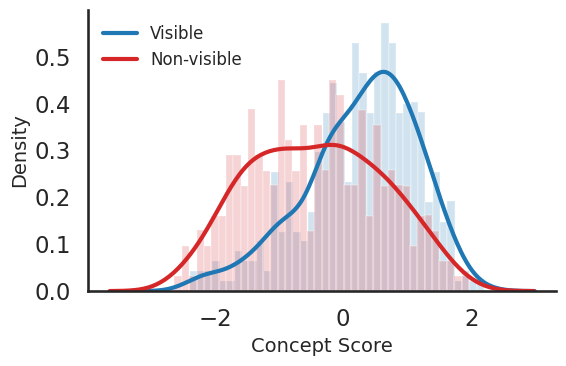

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# スタイル（背景なし＋太め）
sns.set(style="white")
sns.set_context("talk")  # フォント大きめ

plt.figure(figsize=(6,4))

# カラー（論文向けコントラスト）
color_pos = "#1f77b4"   # blue
color_neg = "#d62728"   # red

# histogram（薄く）
plt.hist(scores_pos, bins=40, density=True, alpha=0.2, color=color_pos)
plt.hist(scores_neg, bins=40, density=True, alpha=0.2, color=color_neg)

# KDE（強調）
sns.kdeplot(scores_pos, linewidth=3, color=color_pos, label="Visible")
sns.kdeplot(scores_neg, linewidth=3, color=color_neg, label="Non-visible")

# ラベル（少し大きめ）
plt.xlabel("Concept Score", fontsize=14)
plt.ylabel("Density", fontsize=14)

# 凡例
plt.legend(frameon=False, fontsize=12)

# 枠削除（重要）
sns.despine()

plt.tight_layout()
plt.savefig('pet_ours02.png', dpi=600)
plt.show()